The original notebook is taken from the following GitHub repository, which was written by **Dr. Tanveer Karim**: https://github.com/tanveerkarim/myTutorials/blob/main/notebooks/healpy-sims.ipynb

# Requirements for Making Gaussian Simulations with healpy

## Core Packages
- `healpy` (for working with HEALPix maps and spherical harmonics)
- `numpy` (for numerical operations)
- `matplotlib` (for visualization)

## Power Spectrum Generators (Choose one)
- `camb` (for generating CMB and matter power spectra)
- `CLASS` (an alternative to CAMB, also computes CMB and matter power spectra)


## Installation Commands (Run in Colab)
```bash
!pip install healpy camb pyccl
```

In [105]:
!pip install healpy camb pyccl --quiet

In [106]:
# Check installed packages
import importlib

for pkg in ['healpy', 'camb', 'pyccl']:
    print(f"{pkg}: {'✓' if importlib.util.find_spec(pkg) else '✗'}")

healpy: ✓
camb: ✓
pyccl: ✓


In [107]:
# Import libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb import model, initialpower
import healpy as hp

# Set ggplot style for nicer plots
plt.style.use("ggplot")

For demonstration purposes, `camb` is used to generate the CMB temperature-temperature power spectrum $C_{TT}(\ell)$. However, the power spectrum $C(\ell)$ for any desired tracer should be generated using custom analysis code.

In [108]:
# run camb to get projected power spectrum C_ell

# Set the cosmological parameters
pars =  camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)

# Get the results based on the parameters
results = camb.get_results(pars)

# Get the CMB power spectra (as an example, C_TT power spectrum))
powers =results.get_cmb_power_spectra(pars, CMB_unit='muK')

# Extract the total temperature-temperature power spectrum (C_TT)
cl_TT_tot = powers['total'][:,0]

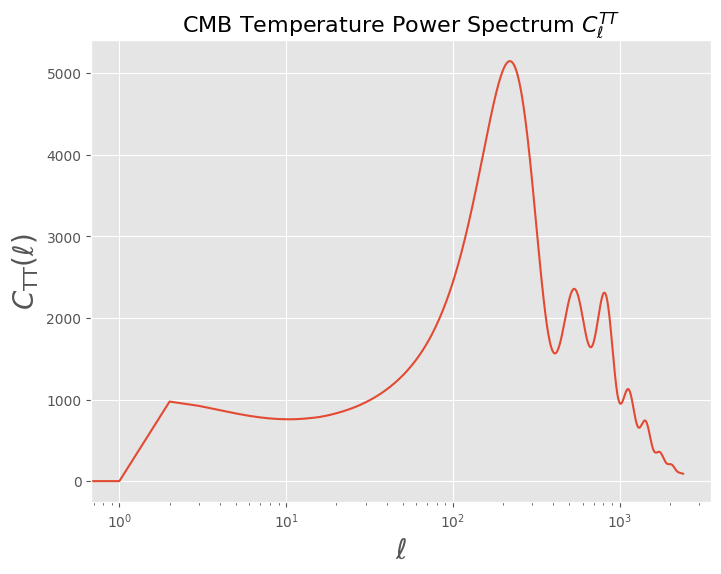

In [109]:
# Generate the ell values ranging from 0 to the max ell produced by CAMB
ells = np.arange(len(cl_TT_tot))

# Plot the C_TT power spectrum using a logarithmic x-axis
plt.figure(figsize=(8, 6))
plt.semilogx(ells, cl_TT_tot)
plt.xlabel(r"$\ell$", fontsize=20)
plt.ylabel(r"$C_{\rm TT} (\ell)$", fontsize=20)
plt.title('CMB Temperature Power Spectrum $C_\ell^{TT}$', fontsize=16)
plt.grid(True)
plt.show()

# Mapmaking from theory $C(\ell)$

This section demonstrates how to generate map realizations using theoretical power spectra, with the `healpy` package serving as the primary tool.  

`healpy` is a widely-used package for projected power spectra analysis, built on the `HEALPix` codebase.  

The power spectrum $C(\ell)$ describes the variance of overdensity at each scale when the mean is zero. Note that the mean can always be subtracted to transform any map to have zero mean, without affecting the variance of the overdensity field. This property can be verified through direct calculation.

The `healpy.synfast` function operates by sampling Gaussian random numbers with mean zero and variance specified by $C(\ell)$ at each scale. These realizations are combined to produce a complete map. The mandatory arguments are:

- **cls**: The input power spectrum is specified via this parameter. Though `synfast` has capability for multiple cls arrays, detailed discussion of this feature is deferred to the following section.
- **nside**: Determines the resolution of the HEALPix pixelization scheme. The base resolution consists of 12 equal-area pixels $(nside=1)$. Higher resolutions are achieved by recursively dividing each pixel into four smaller pixels. The total number of pixels is given by $N_{\text{pix}} = 12 \times \text{NSIDE}^2$. For this demonstration, $NSIDE=1024$ is used, corresponding to $1024^2$ subdivisions of each base pixel.
- **pol**: A boolean flag indicating whether the map contains polarization information. Since overdensity fields (such as galaxy distributions or lensing maps) are not polarized, this is set to `False`. Polarized fields require additional considerations as described in the `healpy` documentation.

In [110]:
# NSIDE (resolution for the map)
NSIDE = 1024

# Generate a CMB map realization using synfast with the C_TT power spectrum
map_realization = hp.synfast(cls=cl_TT_tot, nside=NSIDE, pol=False)

| Functionality | Description |
|---|---|
| `healpy` visualization tools | The created map can be examined using healpy's visualization capabilities. |
| Customization options | Optional arguments including the map's `min` and `max` values, color scheme `cmap`, and `title` may be specified. |

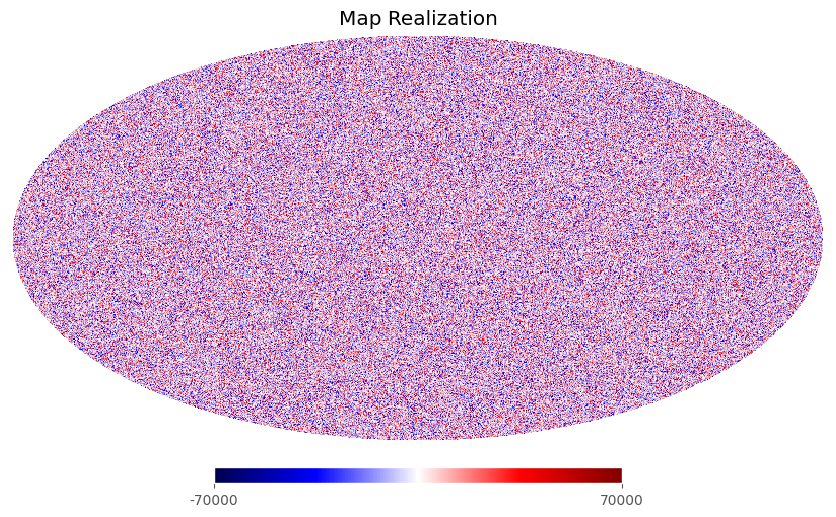

In [111]:
# Plot the CMB map with custom settings
hp.mollview(map_realization,
            min=-70000, max=70000,
            cmap='seismic',
            title='Map Realization')

plt.show()

## Map Simulation and Verification

The first simulation map has now been generated.

To verify that the generated map maintains the input power spectrum used in `synfast`, the `healpy` function `anafast` can be utilized. This function performs a spherical harmonics transform on the input map to reconstruct its power spectrum.

In [112]:
# Compute the angular power spectrum from the simulated map
cl_TT_tot_measured = hp.anafast(map_realization, pol=False)

## Power Spectrum Comparison

The measured $C(\ell)$ can now be plotted alongside the original input spectrum.

Several considerations should be noted:
- At very low $\ell$ values (large scales), the spectrum may appear affected by cosmic variance
- Alternative algorithms like Fast-Fourier Transforms are available for measuring these large scales
- For this analysis, $\ell_{\min} = 50$ is chosen as the lower bound

Similarly, $\ell_{\max} = 2000$ is selected because:
- HEALPix measures power spectra up to $3 \times \text{NSIDE} - 1$ by design
- To enable direct comparison, the range is limited to match the input power spectrum

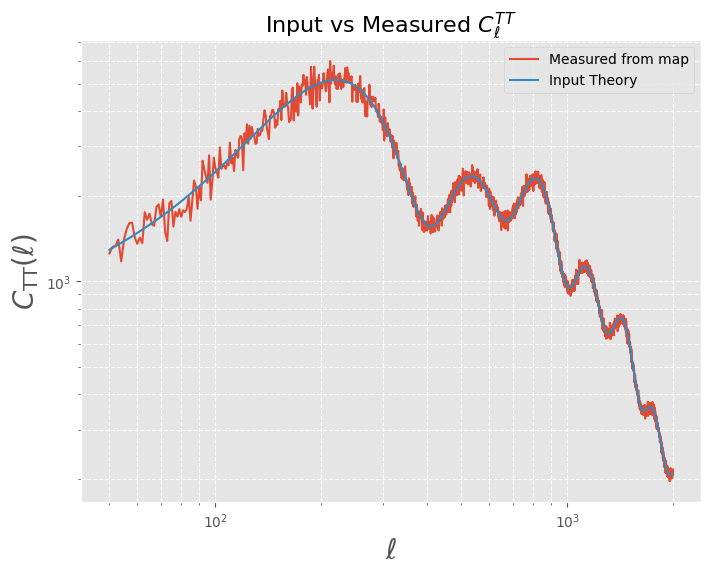

In [113]:
# Define the multipole range for plotting
LMIN = 50
LMAX = 2000

# Create the ell array (make sure it's long enough)
ells = np.arange(len(cl_TT_tot))

# Plot the measured and theoretical power spectra
plt.figure(figsize=(8, 6))
plt.loglog(ells[LMIN:LMAX], cl_TT_tot_measured[LMIN:LMAX],
           label='Measured from map')
plt.loglog(ells[LMIN:LMAX], cl_TT_tot[LMIN:LMAX],
           label='Input Theory')

plt.legend(loc='best')
plt.xlabel(r"$\ell$", fontsize=20)
plt.ylabel(r"$C_{\rm TT} (\ell)$", fontsize=20)
plt.title("Input vs Measured $C_\ell^{TT}$", fontsize=16)
plt.grid(True, which='both', ls='--')
plt.show()

# Advanced: Correlated Mapmaking

## Correlated Field Simulations

When multiple maps need to be generated from related sets of power spectra, such as in joint analyses of galaxy clustering and CMB lensing, special consideration is required. Both fields originate from the same underlying matter distribution, yet if simulated independently using only their individual power spectra ($C_{gg}(\ell)$ for galaxies and $C_{\kappa\kappa}(\ell)$ for lensing convergence), their cross-correlation will evaluate to zero.

## Implementation Method

To properly capture these correlations, the simulation function `synfast` must be provided with the complete covariance structure. For demonstration purposes, the `pyccl` package can be utilized to generate the required set of correlated power spectra efficiently.

Note: The specific `pyccl` arguments are not the focus of this demonstration and may be explored separately.

In [114]:
# use pyccl to generate galaxy clustering and CMB lensing power spectra

import pyccl as ccl


# Define a flat LCDM cosmology
cosmo = ccl.Cosmology(
    Omega_c=0.27,        # Cold dark matter density
    Omega_b=0.045,       # Baryon density
    h=0.67,              # Hubble parameter (H0/100)
    A_s=2.1e-9,          # Amplitude of scalar fluctuations
    n_s=0.96             # Spectral index
)

# Redshift grid
z = np.linspace(0, 1.2, 10)

# Galaxy redshift distribution (dN/dz), modeled as a Gaussian centered at z=0.5
nz = np.exp(-((z - 0.5)/0.05)**2 / 2)

# Linear galaxy bias (constant over z for simplicity)
bz = 0.95 * np.ones_like(z)

# Define the galaxy number counts tracer (no RSD, no magnification bias)
galaxy = ccl.NumberCountsTracer(
    cosmo, has_rsd=False,
    dndz=(z, nz),
    bias=(z, bz),
    mag_bias=None
)

# Define the CMB lensing tracer (source redshift ~1100)
cmbl = ccl.CMBLensingTracer(cosmo, z_source=1100.)

# Define multipole range
ells = np.arange(2, 2001)

# Compute theoretical angular power spectra:
cl_gg_th = ccl.angular_cl(cosmo, galaxy, galaxy, ells)  # Galaxy auto-spectrum
cl_kk_th = ccl.angular_cl(cosmo, cmbl, cmbl, ells)      # CMB lensing auto-spectrum
cl_kg_th = ccl.angular_cl(cosmo, cmbl, galaxy, ells)    # Galaxy–CMB lensing cross-spectrum

## Correlated Power Spectrum Implementation

The final three lines represent the most critical steps, where theory power spectra are generated for:
1. Galaxy-galaxy clustering ($C_{gg}(\ell)$)
2. Lensing-lensing clustering ($C_{\kappa\kappa}(\ell)$)
3. Lensing-galaxy clustering ($C_{g\kappa}(\ell)$)

The cross-power spectrum $C_{g\kappa}(\ell)$ enables `synfast` to produce properly correlated map realizations.

## Syntax and Generalization

The same basic syntax is employed, but with a list of three power spectra arrays passed to `synfast`, which then generates two correlated maps. This approach can be extended to arbitrary numbers of correlated fields, provided that:

1. All auto-correlation spectra ($C_{ii}(\ell)$) for each field are included
2. All cross-correlation spectra ($C_{ij}(\ell)$) between fields are specified

In [115]:
import healpy as hp

# Simulate correlated Gaussian maps using synfast
# cls must be a list of [C_gg, C_gk, C_kk], all arrays of shape (N_ell,)
# They are ordered as: [[C_00], [C_01], [C_11]] in a 2x2 matrix

sim_galaxy, sim_lensing = hp.synfast(
    cls=[cl_gg_th, cl_kg_th, cl_kk_th],
    nside=NSIDE,
    pol=False,
    new=True  # ensures output is returned instead of being plotted
)


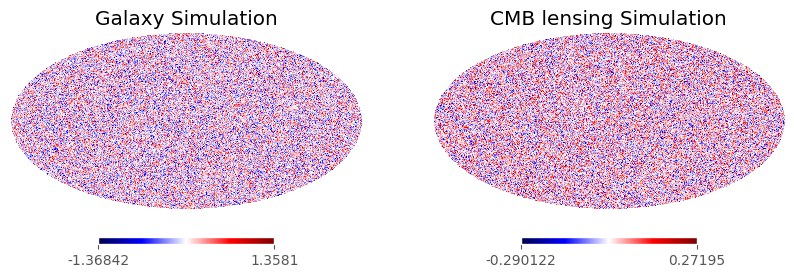

In [116]:
fig, (ax1, ax2) = plt.subplots(figsize = (10,7), ncols=2)

plt.axes(ax1)
hp.mollview(sim_galaxy, hold=True, cmap='seismic',
            title = 'Galaxy Simulation')

plt.axes(ax2)
hp.mollview(sim_lensing, hold=True, cmap = 'seismic',
            title = 'CMB lensing Simulation')

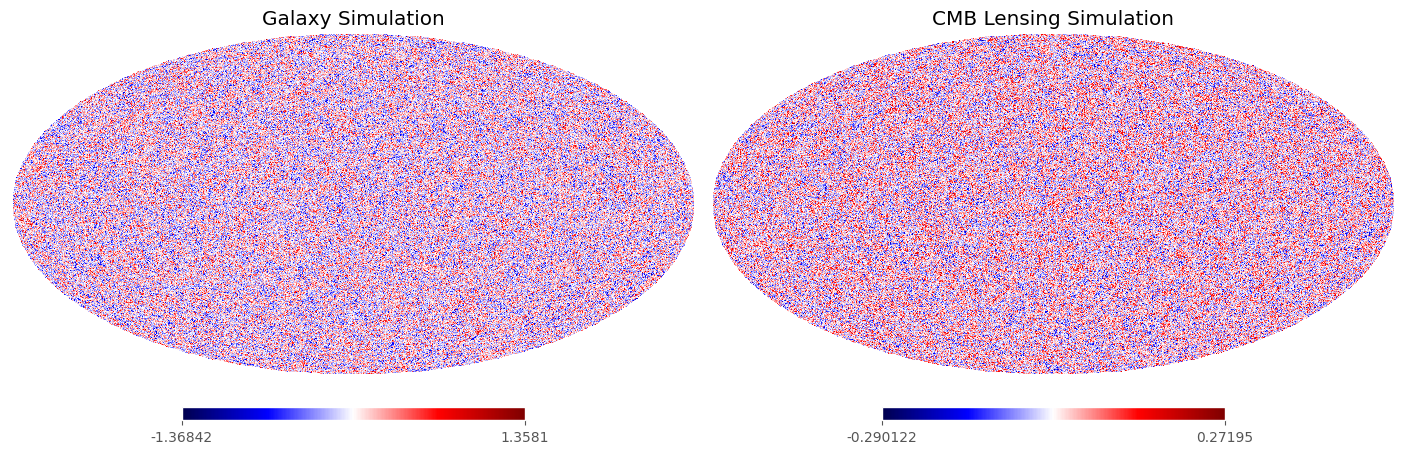

In [117]:
# Create a figure and set the size
plt.figure(figsize=(14, 6))

# Left subplot: Galaxy simulation
hp.mollview(sim_galaxy, sub=(1, 2, 1), title='Galaxy Simulation', cmap='seismic')

# Right subplot: CMB lensing simulation
hp.mollview(sim_lensing, sub=(1, 2, 2), title='CMB Lensing Simulation', cmap='seismic')

plt.show()

In [118]:
# Measure power spectra from simulated maps

# Galaxy auto-spectrum
cl_gg_measured = hp.anafast(sim_galaxy, pol=False)

# CMB lensing auto-spectrum
cl_kk_measured = hp.anafast(sim_lensing, pol=False)

# Galaxy–CMB lensing cross-spectrum
cl_kg_measured = hp.anafast(sim_lensing, sim_galaxy, pol=False)

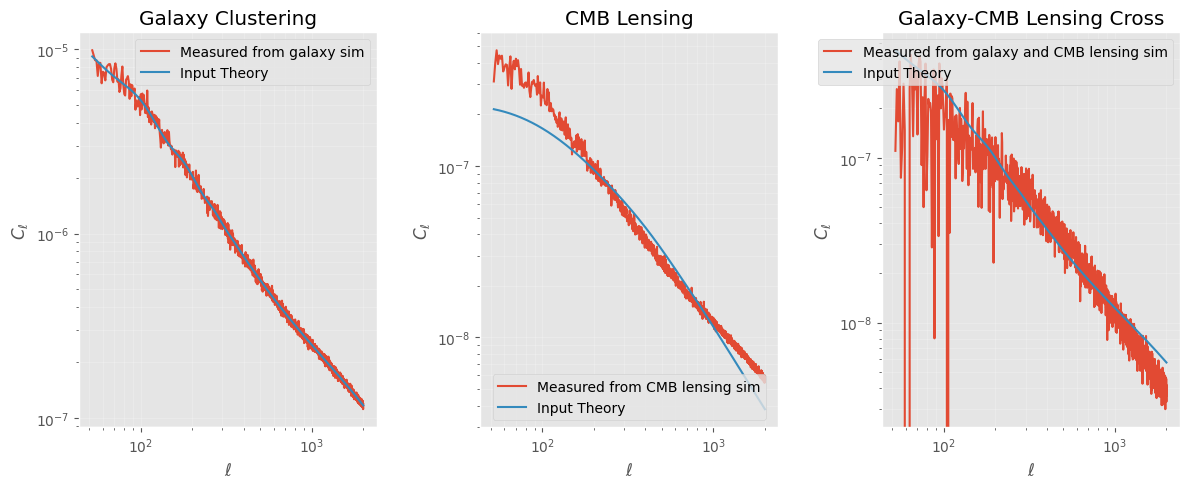

In [119]:
# Assuming you have these variables defined elsewhere:
# ells, cl_gg_measured, cl_gg_th, cl_kk_measured, cl_kk_th, cl_kg_measured, cl_kg_th, LMIN, LMAX

# First, verify and adjust array lengths to match
min_length = min(len(ells),
                 len(cl_gg_measured), len(cl_gg_th),
                 len(cl_kk_measured), len(cl_kk_th),
                 len(cl_kg_measured), len(cl_kg_th))

# Adjust LMAX if it exceeds the minimum length
LMAX = min(LMAX, min_length)

# Create the figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(12, 5), ncols=3)

# Galaxy auto-spectrum plot
ax1.loglog(ells[LMIN:LMAX],
           cl_gg_measured[LMIN:LMAX],
           label='Measured from galaxy sim')
ax1.loglog(ells[LMIN:LMAX], cl_gg_th[LMIN:LMAX],
           label='Input Theory')
ax1.set_title('Galaxy Clustering')
ax1.legend(loc='best')

# CMB lensing auto-spectrum plot
ax2.loglog(ells[LMIN:LMAX],
           cl_kk_measured[LMIN:LMAX],
           label='Measured from CMB lensing sim')
ax2.loglog(ells[LMIN:LMAX], cl_kk_th[LMIN:LMAX],
           label='Input Theory')
ax2.set_title('CMB Lensing')
ax2.legend(loc='lower center')

# Cross-spectrum plot
ax3.loglog(ells[LMIN:LMAX],
           cl_kg_measured[LMIN:LMAX],
           label='Measured from galaxy and CMB lensing sim')
ax3.loglog(ells[LMIN:LMAX], cl_kg_th[LMIN:LMAX],
           label='Input Theory')
ax3.set_title('Galaxy-CMB Lensing Cross')
ax3.legend(loc='best')

# Common labels
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel(r"$\ell$", fontsize=12)
    ax.set_ylabel(r"$C_{\ell}$", fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()